# Organized clonotype analysis notebook

This notebook was reorganized by adding markdown headers only. The original code cells were preserved unchanged and kept in their original order.

## Table of contents

1. Setup and imports
2. Data loading and metadata preparation
3. Initial visualization and filtering
4. TCR chain indexing and quality control
5. AIRR filtering
6. Clonotype definition and clonotype network
7. TCRdist clonotype clusters
8. CDR3 extraction and top clonotype inspection
9. V-gene-aware clonotype definition
10. Clonal expansion analysis
11. Differential expression in selected clonotypes
12. Gene usage analysis


## TCR analysis

# 1. Setup and imports

Libraries used for MuData, scirpy, plotting, and downstream analysis.


In [1]:
# =========================
# Standard library
# =========================
import os
from pathlib import Path
from functools import partial
from multiprocessing import Pool
from typing import Optional

# =========================
# Core scientific computing
# =========================
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation

# =========================
# Single-cell analysis
# =========================
import anndata as ad
from anndata import AnnData

import scanpy as sc
import scirpy as ir
#import muon as mu
#from muon import MuData
#import mudata as mu
import muon as mu
import palantir
import decoupler as dc

# =========================
# Differential expression
# =========================
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

try:
    # newer pydeseq2
    from pydeseq2.default_inference import DefaultInference
except Exception:
    # older pydeseq2
    from pydeseq2.dds import DefaultInference

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.pyplot import rc_context
from matplotlib import cm as mpl_cm
from cycler import cycler
from matplotlib_venn import venn3

import seaborn as sns
import altair as alt

# Enable Altair backend
alt.data_transformers.enable("vegafusion")


I0000 00:00:1786434932.518344 3294602 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786434932.584605 3294602 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786434934.423683 3294602 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


DataTransformerRegistry.enable('vegafusion')

## Import data

# 2. Data loading and metadata preparation

Load the MuData object and harmonize sample, treatment, condition, and annotation metadata.


In [2]:
mdata = mu.read_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/002_annotate_mudata_normal.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/anndata/utils.py:354: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


# 3. Initial visualization and filtering

Inspect annotations on UMAP and remove unwanted cell populations.


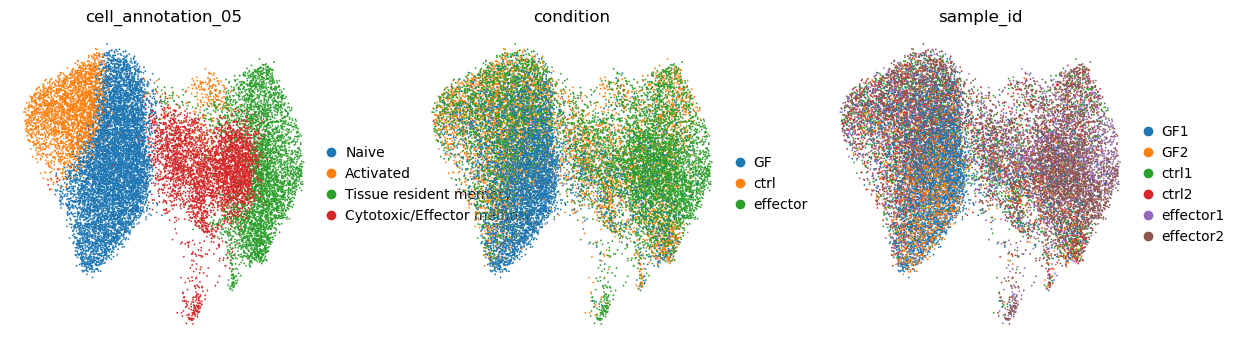

In [3]:
sc.pl.umap(mdata["gex"], color=["cell_annotation_05","condition","sample_id"], frameon=False)

## Creating chain indices & TCR Quality Control

# 4. TCR chain indexing and quality control

Index AIRR chains and evaluate receptor subtype / chain pairing quality.


In [4]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

... storing 'airr:receptor_type' as categorical
... storing 'airr:receptor_subtype' as categorical
... storing 'airr:chain_pairing' as categorical
... storing 'airr:receptor_type' as categorical
... storing 'airr:receptor_subtype' as categorical
... storing 'airr:chain_pairing' as categorical


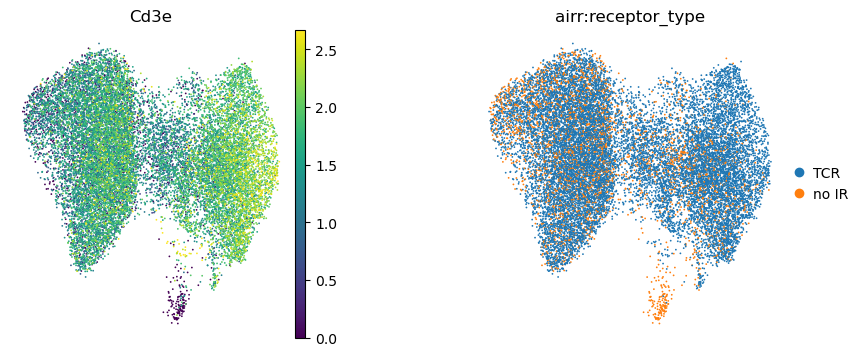

In [5]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={"wspace": 0.5})
mu.pl.embedding(mdata, basis="gex:umap", color=["Cd3e"], ax=ax0, show=False, frameon=False, cmap= "viridis", vmax= "p99")
mu.pl.embedding(mdata, basis="gex:umap", color=["airr:receptor_type"], ax=ax1, frameon=False)

... storing 'airr:receptor_type' as categorical
... storing 'airr:receptor_subtype' as categorical
... storing 'airr:chain_pairing' as categorical
... storing 'receptor_type' as categorical
... storing 'receptor_subtype' as categorical
... storing 'chain_pairing' as categorical


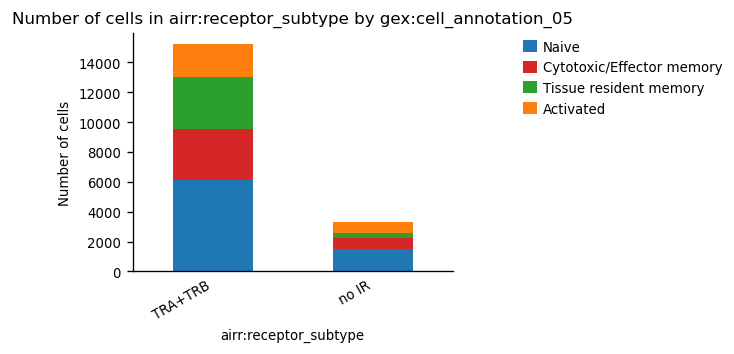

In [6]:
_ = ir.pl.group_abundance(mdata, groupby="airr:receptor_subtype", target_col="gex:cell_annotation_05")

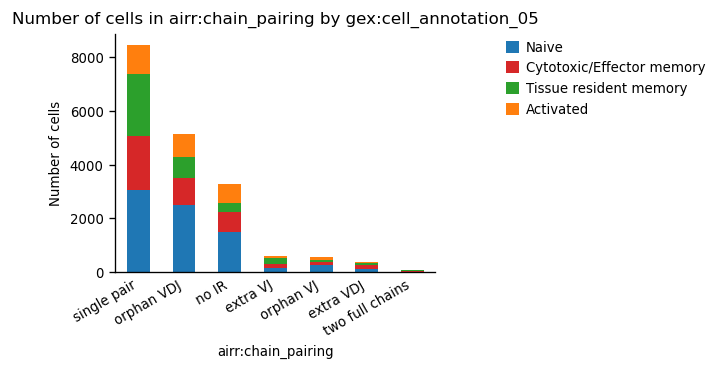

In [7]:
_ = ir.pl.group_abundance(mdata, groupby="airr:chain_pairing", target_col="gex:cell_annotation_05")

In [8]:
print(
    "Fraction of cells with more than one pair of TCRs: {:.2f}".format(
        np.sum(mdata.obs["airr:chain_pairing"].isin(["extra VJ", "extra VDJ", "two full chains", "multichain"]))
        / mdata["airr"].n_obs
    )
)

Fraction of cells with more than one pair of TCRs: 0.07


# 5. AIRR filtering

Filter cells based on TCR chain pairing quality before clonotype analysis.


In [9]:
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: ~np.isin(x, ["orphan VDJ", "orphan VJ"]))

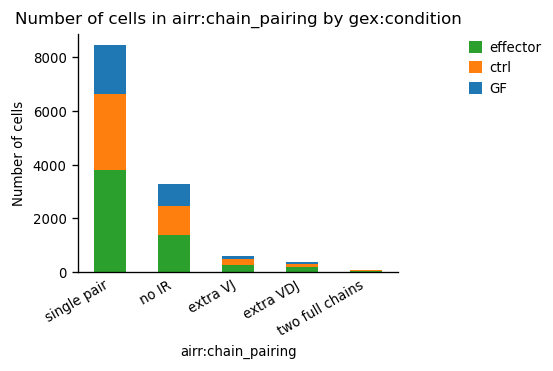

In [10]:
ax = ir.pl.group_abundance(mdata, groupby="airr:chain_pairing", target_col="gex:condition")

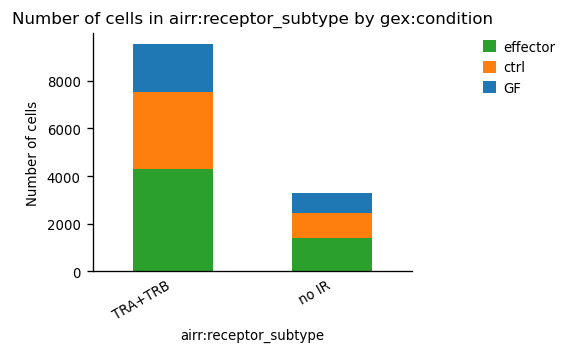

In [11]:
ax = ir.pl.group_abundance(mdata, groupby="airr:receptor_subtype", target_col="gex:condition")

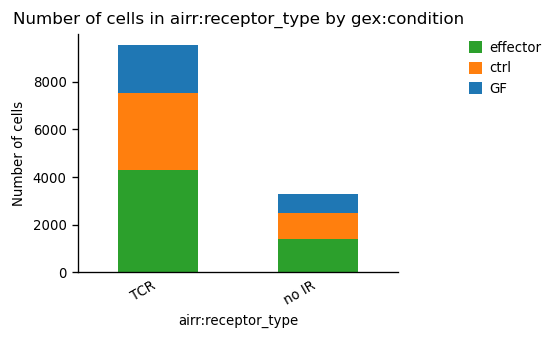

In [12]:
ax = ir.pl.group_abundance(mdata, groupby="airr:receptor_type", target_col="gex:condition")

## After filtering

In [13]:
# cells in AIRR that are TCR
tcr_cells = mdata["airr"].obs_names[
    mdata["airr"].obs["receptor_type"] == "TCR"
]

# keep only those cells in the full MuData object
mdata = mdata[tcr_cells, :].copy()

In [14]:
mdata.update()

In [15]:
mdata["airr"].obs["receptor_type"].value_counts()

receptor_type
TCR    9522
Name: count, dtype: int64

In [16]:
for key in [
    "airr:receptor_type_colors",
    "receptor_type_colors",
]:
    if key in mdata.uns:
        del mdata.uns[key]

In [17]:
mdata["airr"].obs["receptor_type"] = (
    mdata["airr"].obs["receptor_type"]
    .astype("category")
    .cat.remove_unused_categories()
)

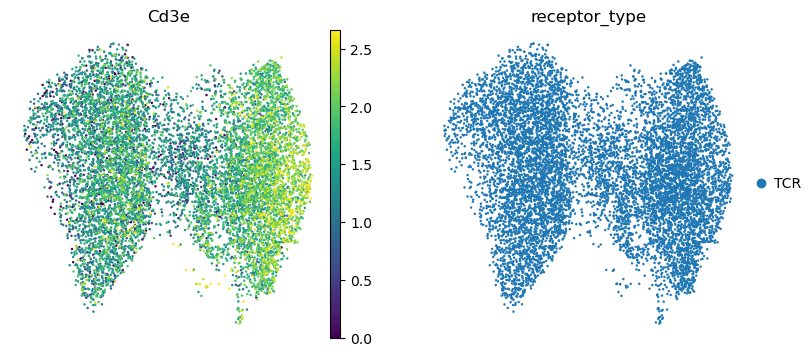

In [18]:
mdata.obs["receptor_type"] = mdata["airr"].obs["receptor_type"].reindex(mdata.obs_names)

mdata.obs["receptor_type"] = (
    mdata.obs["receptor_type"]
    .astype("category")
    .cat.remove_unused_categories()
)

if "receptor_type_colors" in mdata.uns:
    del mdata.uns["receptor_type_colors"]

mu.pl.embedding(
    mdata,
    basis="gex:umap",
    color=["Cd3e","receptor_type"],cmap= "viridis", vmax= "p99",
    frameon=False,
)

## Define clonotypes and clonotype clusters

### Compute CDR3 neighborhood graph and define clonotypes

# 6. Clonotype definition and clonotype network

Define clonotypes from CDR3 sequence similarity and visualize networks by metadata.


In [19]:
# using default parameters, `ir_dist` will compute nucleotide sequence identity
ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")

In [20]:
ir.tl.clonotype_network(mdata, min_cells=10)

In [21]:
mdata.obs.groupby("gex:cell_annotation_05", dropna=False).size()

gex:cell_annotation_05
Naive                        3351
Activated                    1197
Tissue resident memory       2672
Cytotoxic/Effector memory    2302
dtype: int64

... storing 'airr:clone_id' as categorical
... storing 'clone_id' as categorical


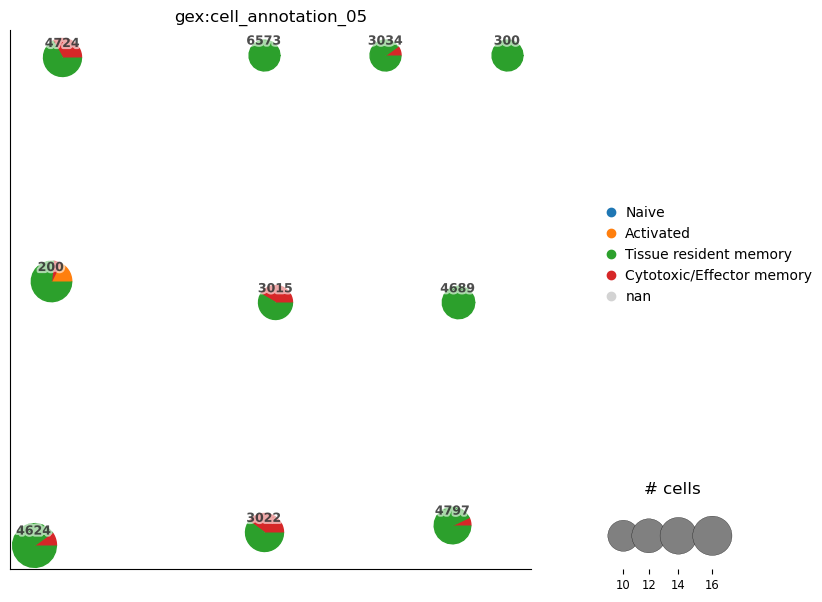

In [22]:
_ = ir.pl.clonotype_network(mdata, color="gex:cell_annotation_05", base_size=50, label_fontsize=9, panel_size=(7, 7))

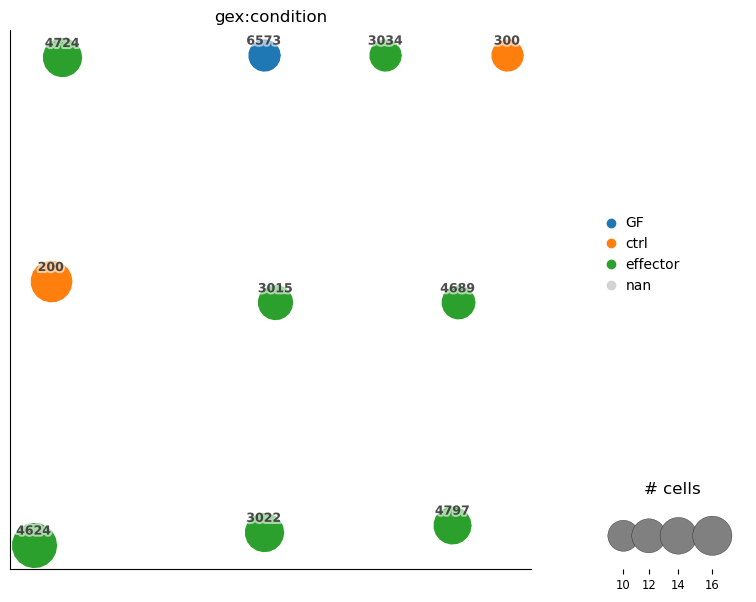

In [23]:
_ = ir.pl.clonotype_network(mdata, color="gex:condition", base_size=50, label_fontsize=9, panel_size=(7, 7))

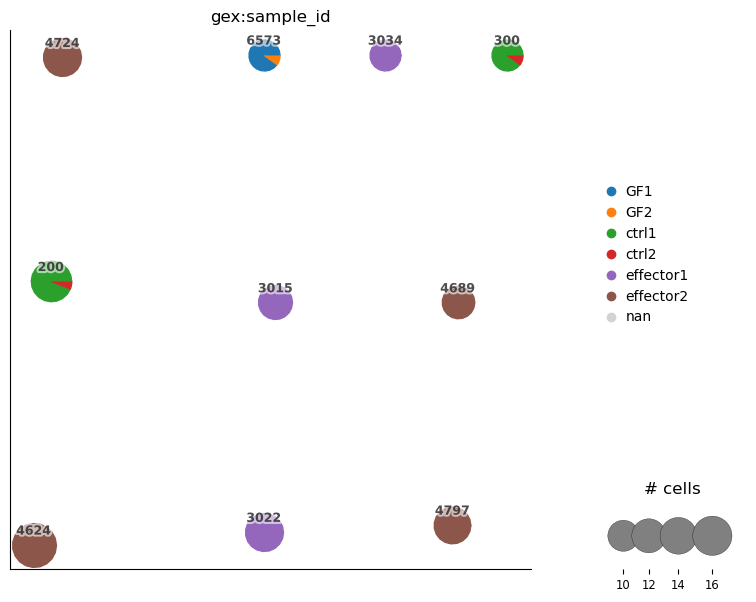

In [24]:
_ = ir.pl.clonotype_network(mdata, color="gex:sample_id", base_size=50, label_fontsize=9, panel_size=(7, 7))

### Re-compute CDR3 neighborhood graph and define clonotype clusters

# 7. TCRdist clonotype clusters

Recompute CDR3 distances using TCRdist and define clonotype clusters.


In [25]:
ir.pp.ir_dist(
    mdata,
    metric="tcrdist",
    sequence="aa",
    cutoff=15,
)

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/scirpy/ir_dist/metrics.py:1356: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  data_rows[row_index][0] = data_row_matrix[thread_id, 0:row_end_index].copy()


In [26]:
ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")

In [27]:
ir.tl.clonotype_network(mdata, min_cells=10, sequence="aa", metric="tcrdist")

... storing 'airr:cc_aa_tcrdist' as categorical
... storing 'cc_aa_tcrdist' as categorical


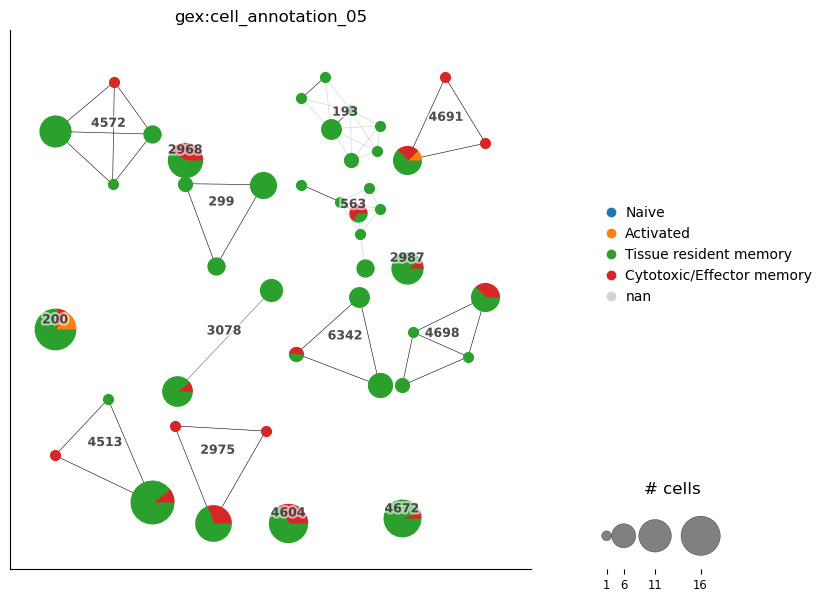

In [28]:
_ = ir.pl.clonotype_network(mdata, color="gex:cell_annotation_05", label_fontsize=9, panel_size=(7, 7), base_size=50, frameon=False)

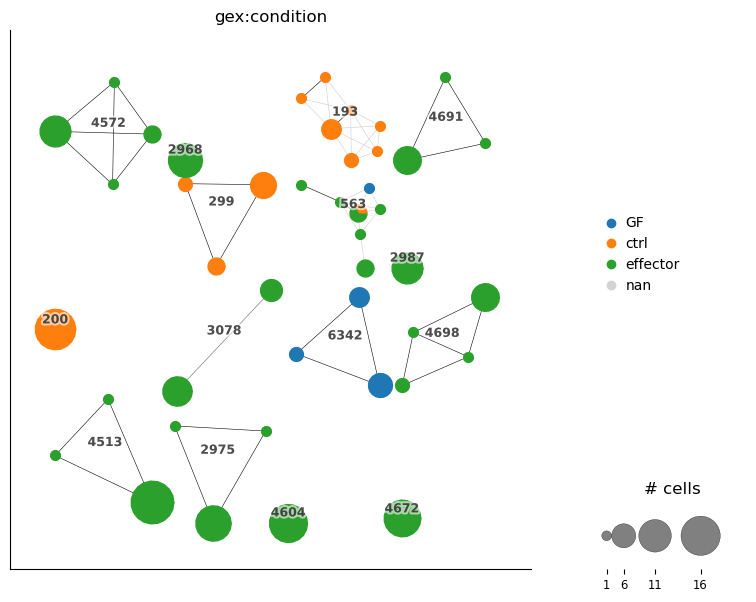

In [29]:
_ = ir.pl.clonotype_network(mdata, color="gex:condition", label_fontsize=9, panel_size=(7, 7), base_size=50, frameon=False)

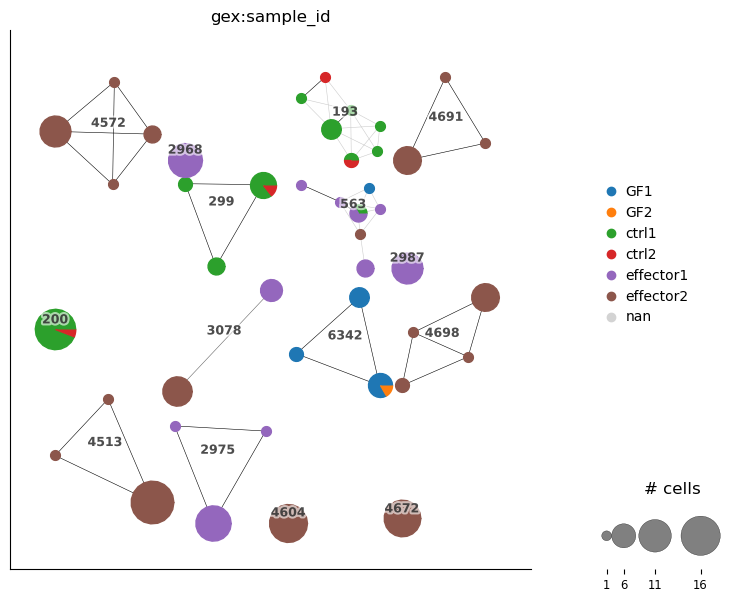

In [30]:
_ = ir.pl.clonotype_network(mdata, color="gex:sample_id", label_fontsize=9, panel_size=(7, 7), base_size=50, frameon=False)

In [31]:
ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")

# 8. CDR3 extraction and top clonotype inspection

Extract CDR3 information and inspect selected clonotype clusters.

Comple clusters are the ones having info for all the regions


In [32]:
cols = [
    "VJ_1_junction_aa",
    "VDJ_1_junction_aa",
    "VJ_2_junction_aa",
    "VDJ_2_junction_aa",
]

with ir.get.airr_context(mdata, "junction_aa", ["VJ_1", "VDJ_1", "VJ_2", "VDJ_2"]):

    cdr3_complete = (
        mdata.obs
        # keep only cells where none of the CDR3 columns are NaN
        .loc[lambda x: x[cols].notna().all(axis=1)]
        .groupby(
            cols + [
                "airr:cc_aa_tcrdist",
                "airr:receptor_subtype",
            ],
            observed=True,
            dropna=False,
        )
        .size()
        .reset_index(name="n_cells")
        .sort_values("n_cells", ascending=False)
    )



... storing 'airr:cc_aa_tcrdist' as categorical
... storing 'VJ_1_junction_aa' as categorical
... storing 'VDJ_1_junction_aa' as categorical
... storing 'VJ_2_junction_aa' as categorical
... storing 'VDJ_2_junction_aa' as categorical
... storing 'cc_aa_tcrdist' as categorical


In [33]:
cdr3_complete

,VJ_1_junction_aa,VDJ_1_junction_aa,VJ_2_junction_aa,VDJ_2_junction_aa,airr:cc_aa_tcrdist,airr:receptor_subtype,n_cells
0,CAAAASSGSWQLIF,CASARGGSPLYF,CAVRSGSWQLIF,CASSLAQGDERLFF,5059,TRA+TRB,1
1,CAAEAMDSNYQLIW,CASSPRTEQFF,CAIDRWVGDNSKLIW,CASSFTGAETLYF,3585,TRA+TRB,1
2,CAAEAQGGSAKLIF,CASSSPEGDYAEQFF,CAVSHVGDNSKLIW,CASGEVNSPLYF,1207,TRA+TRB,1
3,CAAGANTGYQNFYF,CTCSAGHYNSPLYF,CILRDQGGSAKLIF,CASSSGGKANTEVFF,3194,TRA+TRB,1
4,CAAGATGANTGKLTF,CASSDQGLGDYAEQFF,CALRNNYAQGLTF,CASSLSYSQNTLYF,5206,TRA+TRB,1
...,...,...,...,...,...,...,...
84,CSAGDSNYQLIW,CASSRDRGLEQYF,CALADYGSSGNKLIF,CASSLGQDTQYF,3484,TRA+TRB,1
85,CSASKGAGNKLTF,CTCSVQTGPSYEQYF,CAVSHASSGSWQLIF,CASRPGTGNSYEQYF,1985,TRA+TRB,1
86,CVLGELSGSFNKLTF,CASSQDQGAGERLFF,CALSDRNQGKLIF,CASSQDPGGADTQYF,7350,TRA+TRB,1
87,CVLGMNYNQGKLIF,CASSLEGDPETLYF,CAADDTNAYKVIF,CASSNQNTLYF,3748,TRA+TRB,1


In [34]:
# count abundance per clonotype
clone_counts = (
    mdata.obs["airr:clone_id"]
    .value_counts()
    .rename_axis("airr:clone_id")
    .reset_index(name="n_cells")
)

# take top N (same as max_cols=60)
top_clones = clone_counts.head(60)["airr:clone_id"]

In [35]:
top_clones.head()

0    4624
1     200
2    3022
3    4724
4    4797
Name: airr:clone_id, dtype: category
Categories (8520, object): ['0', '1', '2', '3', ..., '8516', '8517', '8518', '8519']

In [36]:
complete_clusters = cdr3_complete["airr:cc_aa_tcrdist"].unique()

In [37]:
complete_clusters

['5059', '3585', '1207', '3194', '5206', ..., '3484', '1985', '7350', '3748', '3558']
Length: 88
Categories (8267, object): ['0', '1', '2', '3', ..., '8263', '8264', '8265', '8266']

In [38]:
clone_to_cluster = (
    mdata.obs[["airr:clone_id", "airr:cc_aa_tcrdist"]]
    .drop_duplicates()
)

In [39]:
top_clone_clusters = clone_to_cluster[
    clone_to_cluster["airr:clone_id"].isin(top_clones)
]["airr:cc_aa_tcrdist"]

# intersection
overlap = set(top_clone_clusters) & set(complete_clusters)

overlap

{'193', '3061', '4487', '4564', '532'}

In [40]:
top_complete = clone_to_cluster[
    (clone_to_cluster["airr:clone_id"].isin(top_clones)) &
    (clone_to_cluster["airr:cc_aa_tcrdist"].isin(complete_clusters))
]

top_complete

,airr:clone_id,airr:cc_aa_tcrdist
ACTGAACAGGACATTA-1_10mix1,193,193
CATGCCTGTCGGATCC-1_10mix1,538,532
ACGATGTTCTATCCTA-1_11mix1,3110,3061
AAACCTGAGTGCCATT-1_11mix2,4597,4487
AAGGAGCTCGCCCTTA-1_11mix2,4681,4564


## Top clones

... storing 'airr:cc_aa_tcrdist' as categorical


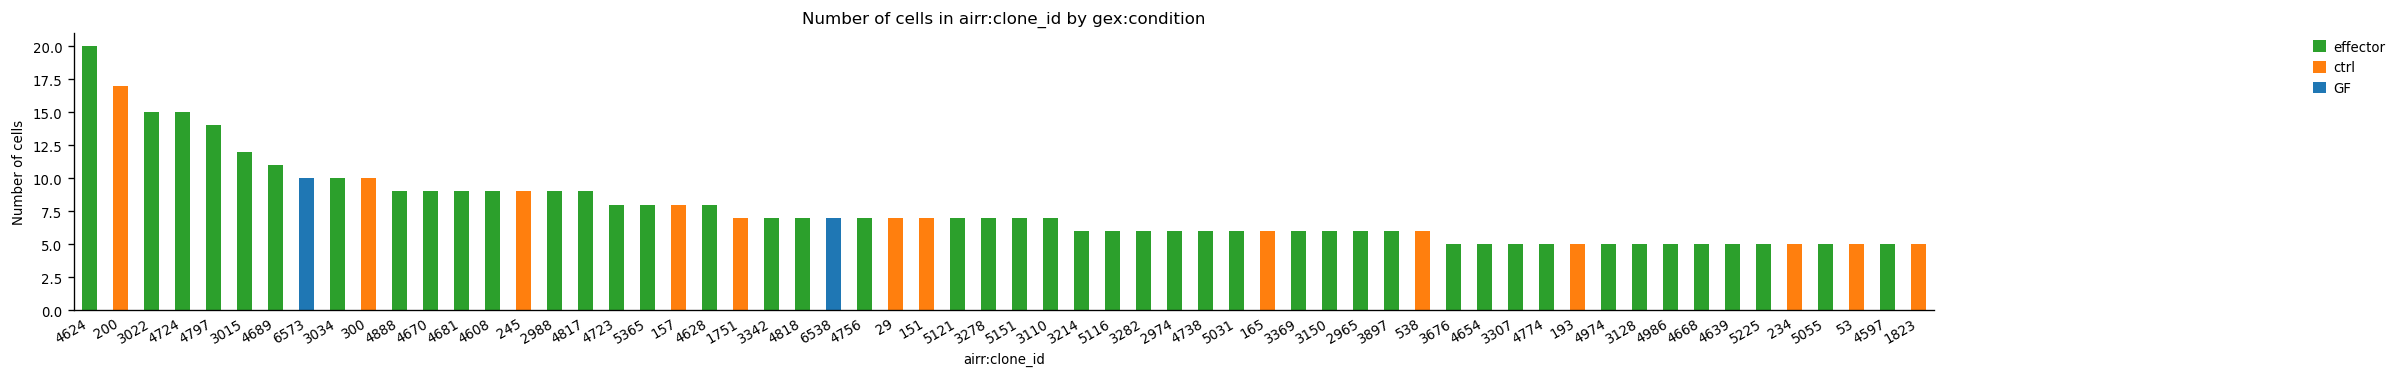

In [41]:
_ = ir.pl.group_abundance(mdata, groupby="airr:clone_id", target_col="gex:condition", max_cols=60, figsize=(20, 3))

## Top clonotypes filtered by threshold  > 100 cells 

In [42]:
import pandas as pd

clone_sizes = (
    mdata.obs["airr:clone_id"]
    .value_counts()
    .rename_axis("clone_id")
    .reset_index(name="n_cells")
)

In [43]:
large_clones = clone_sizes.loc[clone_sizes["n_cells"] > 10]

In [44]:
abundance_df = pd.crosstab(
    mdata.obs["airr:clone_id"],
    mdata.obs["gex:condition"]
)

In [45]:
clone_counts = abundance_df.sum(axis=1)

abundance_df_filtered = abundance_df.loc[clone_counts > 10]

In [46]:
top_clone_ids = abundance_df_filtered.index.to_list()

In [47]:
top_clone_ids

['200', '3015', '3022', '4624', '4689', '4724', '4797']

In [48]:
import scanpy as sc

keep_clones = abundance_df_filtered.index

mdata_large = mdata[
    mdata.obs["airr:clone_id"].isin(keep_clones)
].copy()

In [49]:
mdata_large

MuData object with n_obs × n_vars = 104 × 18038
  obs:	'receptor_type'
  3 modalities
    gex:	104 x 18038
      obs:	'sample_id', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'rna_leiden', 'doublet_score', 'predicted_doublet', 'rna_leiden_12', 'cell_annotation_05'
      var:	'gene_ids', 'feature_types', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
      uns:	'cell_annotation_05_colors', 'condition_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'rna_leiden', 'rna_leiden_12', 'rna_leiden_12_colors', 'rna_leiden_colors', 'sample_id_colors', 'scrublet', 'umap', 'airr:receptor_type_colors', 'receptor_type_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    airr:	104 x 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id', 'clonotype_network', 'ir_dist_aa_tcrdist', 'cc_aa_tcrdist'
      obsm:	'airr', 'chain_indices', 'X_clonotype_network'
    adt:	104 x 0
      obs:	'sample_id'
      var:	'gene_ids', 'feature_types'

<Axes: title={'center': 'Number of cells in airr:clone_id by gex:condition'}, xlabel='airr:clone_id', ylabel='Number of cells'>

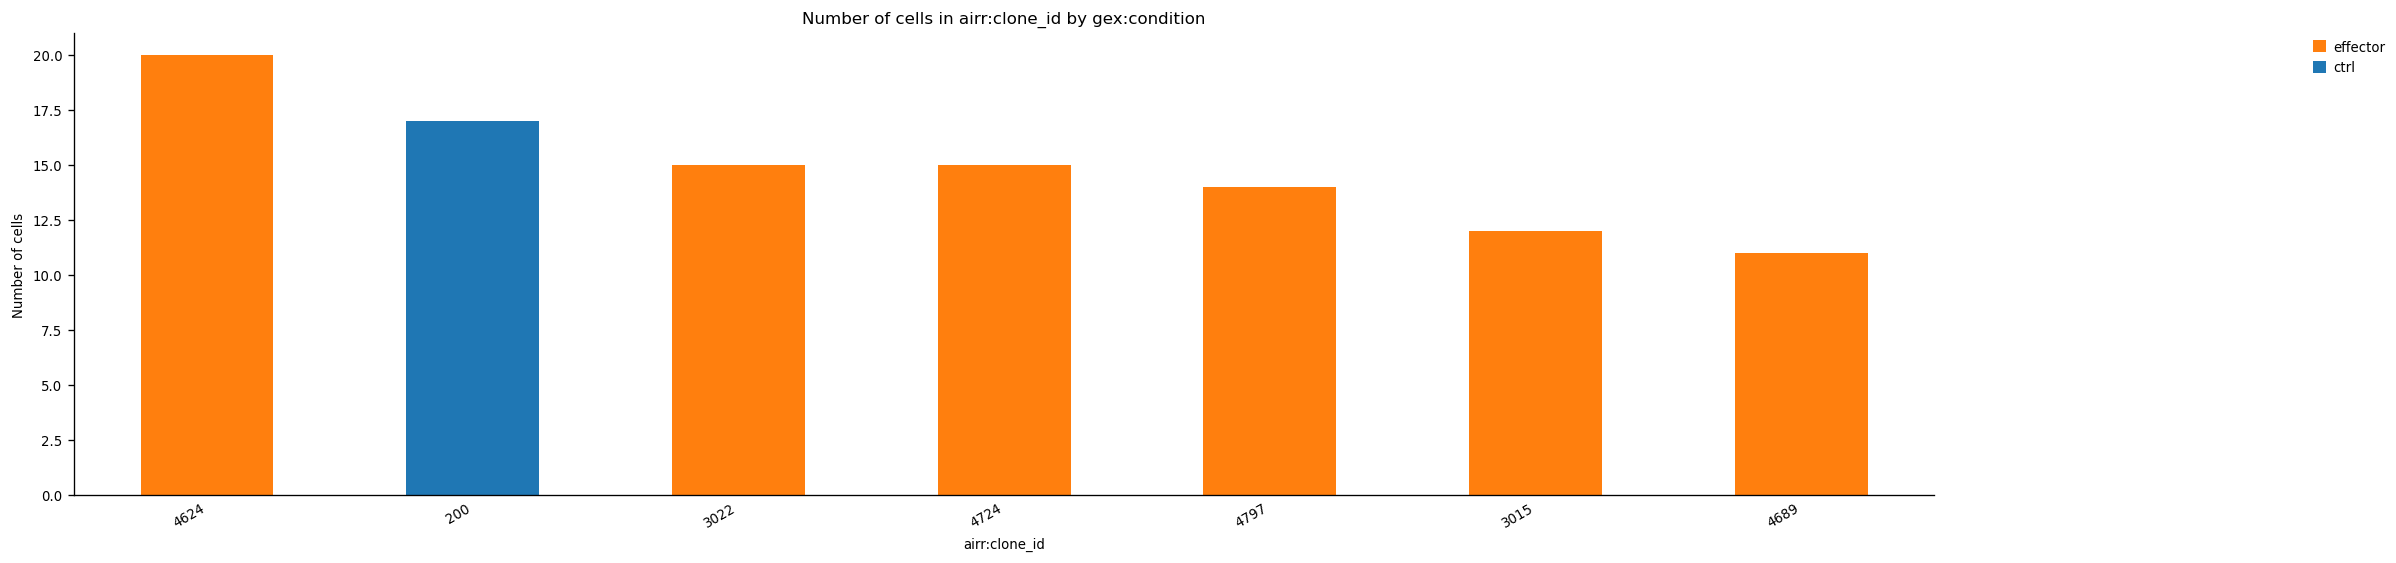

In [50]:
ir.pl.group_abundance(
    mdata_large,
    groupby="airr:clone_id",
    target_col="gex:condition",
    figsize=(20, 5)
)

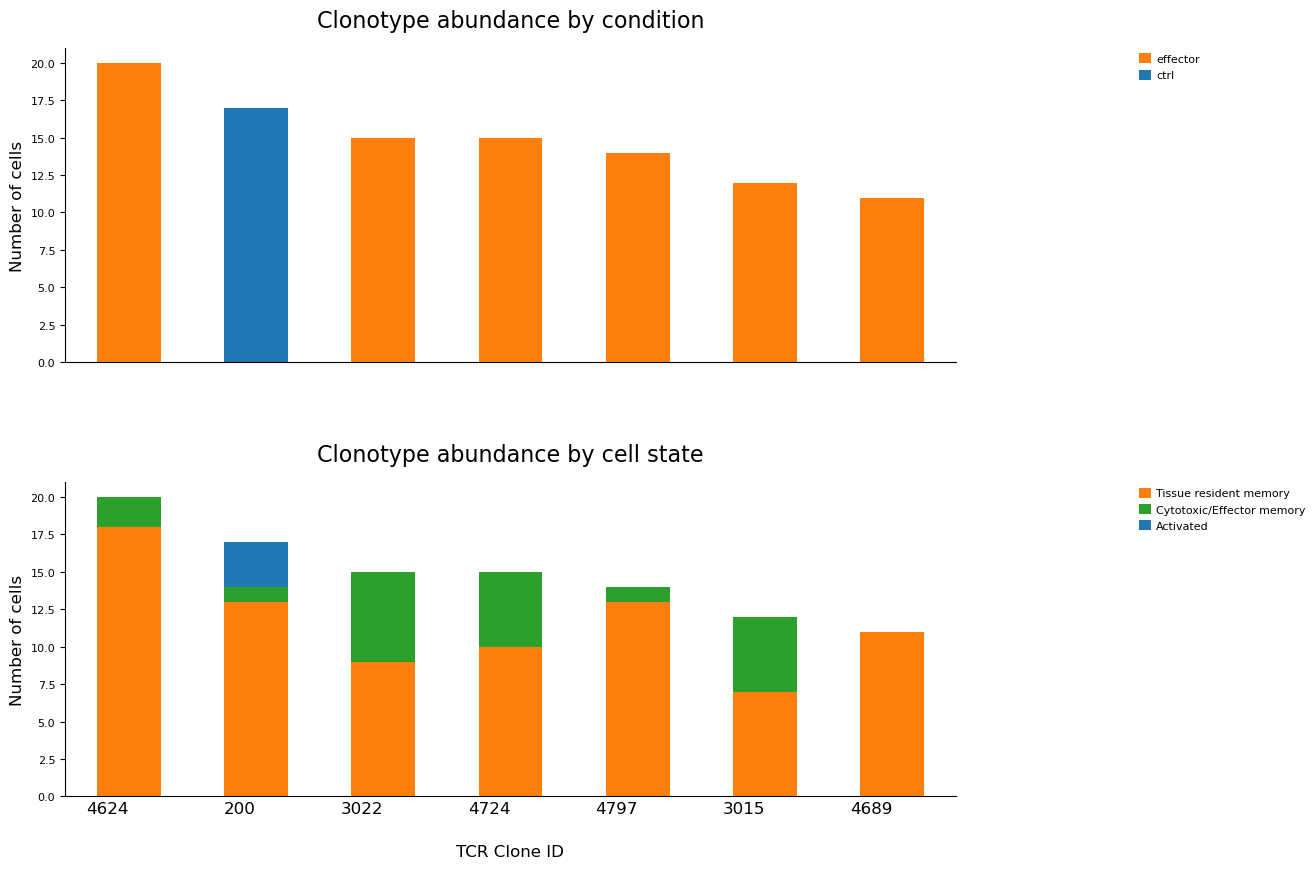

In [51]:
plt.rcParams.update(
    {
        "font.size": 50, 
        "axes.titlesize": 16, 
        "axes.labelsize": 40,  
        "xtick.labelsize": 52,  
        "ytick.labelsize": 14, 
        "legend.fontsize": 13,  
    }
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)


ir.pl.group_abundance(
    mdata_large,
    groupby="airr:clone_id",
    target_col="gex:condition",
    ax=ax1,
   
)
ax1.set_title("Clonotype abundance by condition", pad=15)

ax1.set_xlabel("") 
ax1.set_ylabel("Number of cells",fontsize=12)

ir.pl.group_abundance(
    mdata_large,
    groupby="airr:clone_id",
    target_col="gex:cell_annotation_05",
    ax=ax2,
   
)
ax2.set_title("Clonotype abundance by cell state", pad=15)

ax2.set_xlabel("TCR Clone ID", labelpad=20,fontsize=12)
ax2.set_ylabel("Number of cells",fontsize=12)

plt.xticks(rotation=0, ha="right",fontsize=12)
plt.tight_layout()

output_dir = (
    "/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/"
    "prj_honda_15062026/publication_figures/healthy"
)
os.makedirs(output_dir, exist_ok=True)
plt.savefig(
    os.path.join(output_dir, "clone_abundance_stacked_grid.svg"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

## Explore specific clonotypes

### 4624

In [52]:
with ir.get.airr_context(mdata, "junction_aa", ["VJ_1", "VDJ_1", "VJ_2", "VDJ_2"]):
    cdr3_ct_4624 = (
        # TODO astype(str) is required due to a bug in pandas ignoring `dropna=False`. It seems fixed in pandas 2.x
        mdata.obs.loc[lambda x: x["airr:cc_aa_tcrdist"] == "4624"]
        .astype(str)
        .groupby(
            [
                "VJ_1_junction_aa",
                "VDJ_1_junction_aa",
                "VJ_2_junction_aa",
                "VDJ_2_junction_aa",
                "airr:receptor_subtype",
            ],
            observed=True,
            dropna=False,
        )
        .size()
        .reset_index(name="n_cells")
    )
cdr3_ct_4624

... storing 'VJ_1_junction_aa' as categorical
... storing 'VDJ_1_junction_aa' as categorical
... storing 'VJ_2_junction_aa' as categorical
... storing 'VDJ_2_junction_aa' as categorical


,VJ_1_junction_aa,VDJ_1_junction_aa,VJ_2_junction_aa,VDJ_2_junction_aa,airr:receptor_subtype,n_cells
0,CAASRETGNTGKLIF,CASSWDWGYEQYF,nan,nan,TRA+TRB,3


### 200

In [53]:
with ir.get.airr_context(mdata, "junction_aa", ["VJ_1", "VDJ_1", "VJ_2", "VDJ_2"]):
    cdr3_ct_5967 = (
        # TODO astype(str) is required due to a bug in pandas ignoring `dropna=False`. It seems fixed in pandas 2.x
        mdata.obs.loc[lambda x: x["airr:cc_aa_tcrdist"] == "200"]
        .astype(str)
        .groupby(
            [
                "VJ_1_junction_aa",
                "VDJ_1_junction_aa",
                "VJ_2_junction_aa",
                "VDJ_2_junction_aa",
                "airr:receptor_subtype",
            ],
            observed=True,
            dropna=False,
        )
        .size()
        .reset_index(name="n_cells")
    )
cdr3_ct_5967

... storing 'VJ_1_junction_aa' as categorical
... storing 'VDJ_1_junction_aa' as categorical
... storing 'VJ_2_junction_aa' as categorical
... storing 'VDJ_2_junction_aa' as categorical


,VJ_1_junction_aa,VDJ_1_junction_aa,VJ_2_junction_aa,VDJ_2_junction_aa,airr:receptor_subtype,n_cells
0,CAADTEGADRLTF,CGARDWGDQDTQYF,nan,nan,TRA+TRB,17


### Including the V-gene in clonotype definition

# 9. V-gene-aware clonotype definition

Include V-gene usage in clonotype definitions and inspect clusters with variable V-gene assignments.


In [54]:
ir.tl.define_clonotype_clusters(
    mdata,
    sequence="aa",
    metric="tcrdist",
    receptor_arms="all",
    dual_ir="any",
    same_v_gene=True,
    key_added="cc_aa_tcrdist_same_v",
)

In [55]:
# find clonotypes with more than one `clonotype_same_v`
ct_different_v = mdata.obs.groupby("airr:cc_aa_tcrdist").apply(lambda x: x["airr:cc_aa_tcrdist_same_v"].nunique() > 1)
ct_different_v = ct_different_v[ct_different_v].index.values.tolist()
#ct_different_v

In [56]:
with ir.get.airr_context(mdata, "v_call", ["VJ_1", "VDJ_1","VJ_2","VDJ_2"]):
    ct_different_v_df = (
        mdata.obs.loc[
            lambda x: x["airr:cc_aa_tcrdist"].isin(ct_different_v),
            [
                "airr:cc_aa_tcrdist",
                "airr:cc_aa_tcrdist_same_v",
                "VJ_1_v_call",
                "VDJ_1_v_call"
            ],
        ]
        .sort_values("airr:cc_aa_tcrdist")
        .drop_duplicates()
        .reset_index(drop=True)
    )
ct_different_v_df

... storing 'airr:cc_aa_tcrdist_same_v' as categorical
... storing 'VJ_1_v_call' as categorical
... storing 'VDJ_1_v_call' as categorical
... storing 'VJ_2_v_call' as categorical
... storing 'VDJ_2_v_call' as categorical
... storing 'cc_aa_tcrdist_same_v' as categorical


,airr:cc_aa_tcrdist,airr:cc_aa_tcrdist_same_v,VJ_1_v_call,VDJ_1_v_call
0,6,6,TRAV10,TRBV3
1,6,6275,TRAV4N-3,TRBV12-2
2,6,3042,TRAV6D-6,TRBV14
3,6,1144,TRAV14-2,TRBV16
4,108,354,TRAV6-4,TRBV12-2+TRBV13-2
...,...,...,...,...
169,7233,7311,TRAV7-5,TRBV16
170,7516,7596,TRAV14N-2,TRBV29
171,7516,8010,TRAV14-1,TRBV13-3
172,7555,7636,TRAV12-2,TRBV12-1


## Clonotype analysis

### Clonal expansion

# 10. Clonal expansion analysis

Quantify and visualize clonal expansion across samples, groups, and annotations.


In [57]:
ir.tl.clonal_expansion(mdata, breakpoints=(1, 5,10))

In [58]:
mdata["airr"].obs["clonal_expansion"]

cell_id
AAACCTGAGTCTTGCA-1_10mix1    <= 1
AAACCTGCAGGATCGA-1_10mix1    <= 1
AAACCTGCATACCATG-1_10mix1    <= 1
AAACCTGCATTGAGCT-1_10mix1    <= 1
AAACCTGGTGTGCCTG-1_10mix1    <= 1
                             ... 
TTTCCTCAGGAATGGA-1_GF2       <= 1
TTTGCGCTCAACCATG-1_GF2       <= 1
TTTGCGCTCGGTGTTA-1_GF2       <= 1
TTTGTCAAGGCTAGCA-1_GF2       <= 1
TTTGTCAAGTTGTCGT-1_GF2       <= 1
Name: clonal_expansion, Length: 9522, dtype: category
Categories (5, object): ['<= 1', '<= 5', '<= 10', '> 10', 'nan']

In [59]:
# keep AIRR cells with non-missing clonal_expansion
keep_cells = mdata["airr"].obs_names[
    mdata["airr"].obs["clonal_expansion"].notna()
]

# subset full MuData by shared cell names
mdata_filtered = mdata[keep_cells, :].copy()

In [60]:
# subset cells with non-missing clonal_expansion
keep_cells = mdata["airr"].obs_names[
    mdata["airr"].obs["clonal_expansion"].notna()
]
keep_cells = keep_cells.intersection(mdata["gex"].obs_names)

mdata_filtered = mdata[keep_cells, :].copy()

# clean unused categories
mdata_filtered["airr"].obs["clonal_expansion"] = (
    mdata_filtered["airr"].obs["clonal_expansion"]
    .cat.remove_unused_categories()
)

# remove old stored colors if present
if "clonal_expansion_colors" in mdata_filtered["airr"].uns:
    del mdata_filtered["airr"].uns["clonal_expansion_colors"]

In [83]:
import matplotlib.pyplot as plt
import muon as mu

# 1. Generate plot without immediately displaying/clearing it (show=False)
mu.pl.embedding(
    mdata_filtered,
    basis="gex:umap",
    color=["airr:clonal_expansion"],
    frameon=True,
    show=False,size =50
)

# 2. Save the active figure directly
plt.savefig(
    "/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/prj_honda_15062026/publication_figures/healthy/gex_umap_clonal_expansion.svg",
    dpi=300,
    bbox_inches="tight",
)

# 3. Close the plot memory buffer
plt.close()

In [66]:
if "airr:clonal_expansion_colors" in mdata_filtered.uns:
    del mdata_filtered.uns["airr:clonal_expansion_colors"]

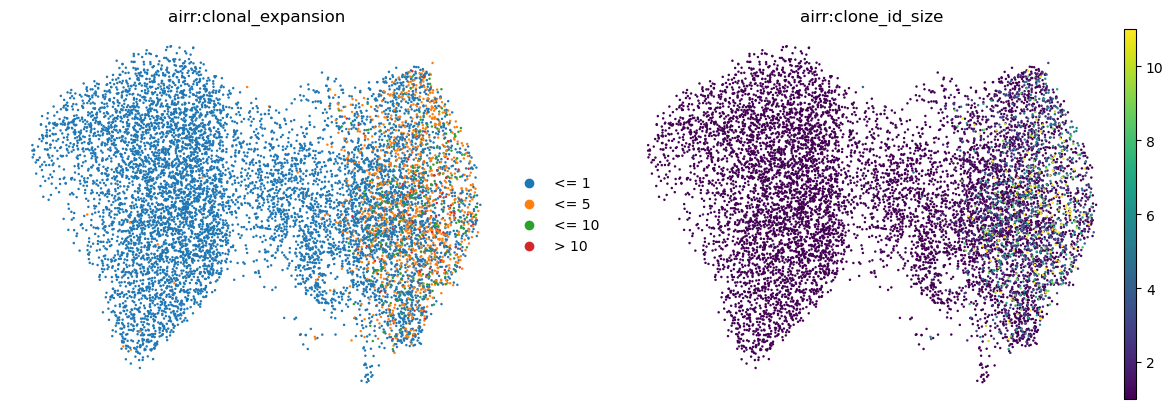

In [67]:
mu.pl.embedding(mdata_filtered, basis="gex:umap", color=["airr:clonal_expansion", "airr:clone_id_size"], frameon=False, vmax="p99")

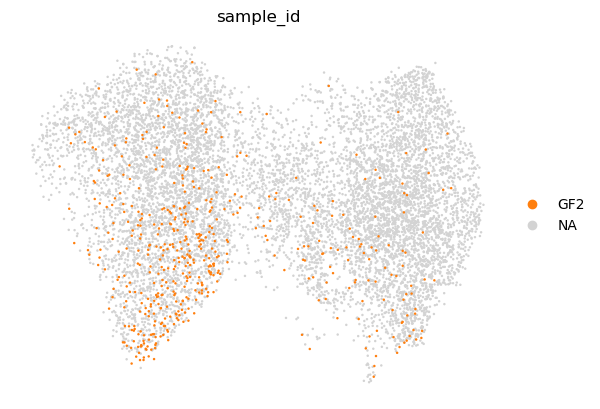

In [68]:
sc.pl.umap(mdata["gex"], color=["sample_id"], groups = ["GF2"], frameon=False)

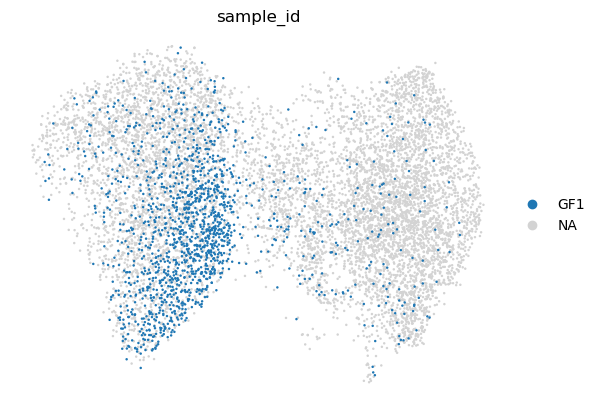

In [69]:
sc.pl.umap(mdata["gex"], color=["sample_id"], groups = ["GF1"], frameon=False)

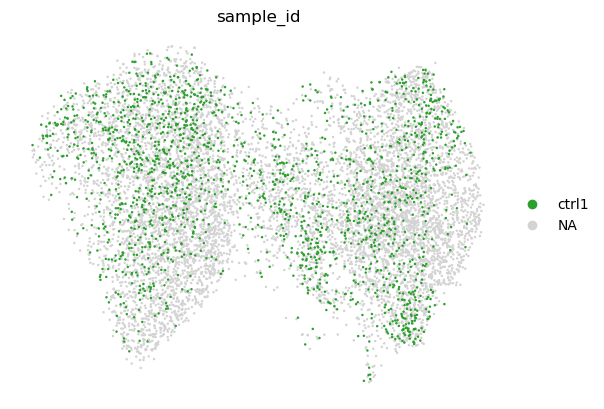

In [70]:
sc.pl.umap(mdata["gex"], color=["sample_id"], groups = ["ctrl1"], frameon=False)

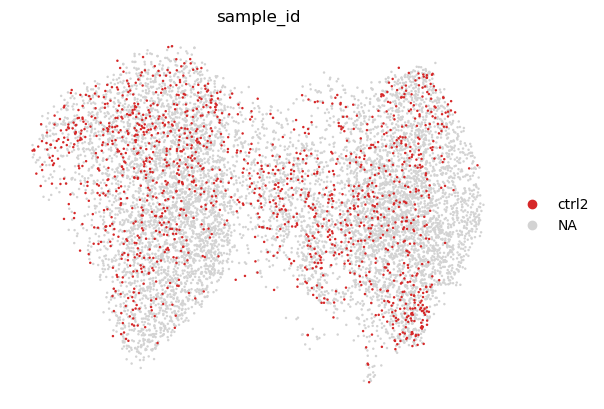

In [71]:
sc.pl.umap(mdata["gex"], color=["sample_id"], groups = ["ctrl2"], frameon=False)

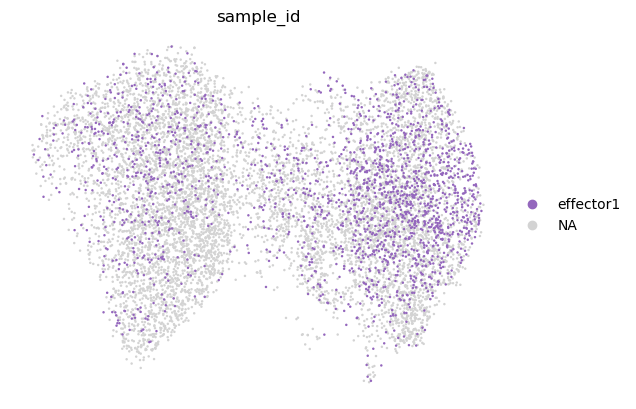

In [72]:
sc.pl.umap(mdata["gex"], color=["sample_id"], groups = ["effector1"], frameon=False)

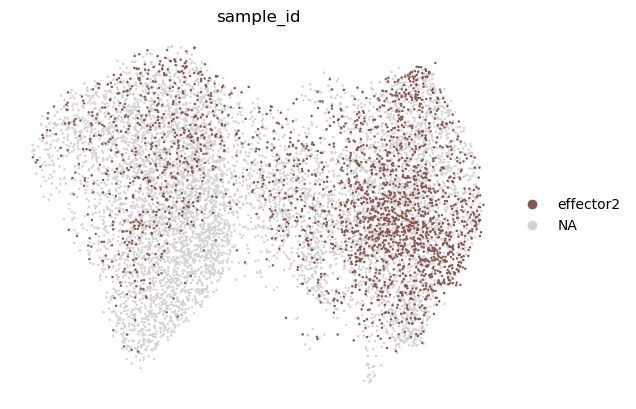

In [73]:
sc.pl.umap(mdata["gex"], color=["sample_id"], groups = ["effector2"], frameon=False)

In [74]:
_ = ir.pl.clonal_expansion(mdata, target_col="clone_id", groupby="gex:condition", breakpoints=(1, 5,10), normalize=True)

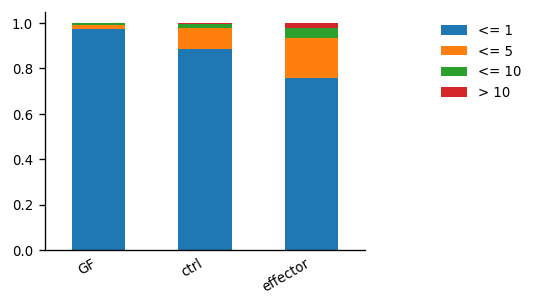

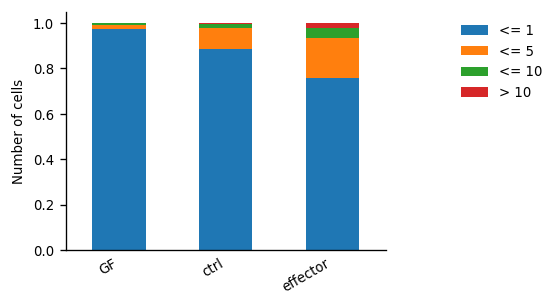

In [75]:
import matplotlib.pyplot as plt
import os

# create output directory
os.makedirs("./figures", exist_ok=True)

# generate plot
_ = ir.pl.clonal_expansion(
    mdata,
    target_col="clone_id",
    groupby="gex:condition",
    breakpoints=(1, 5, 10),
    normalize=True
)

# get current axes and figure
ax = plt.gca()
fig = plt.gcf()

# axis labels and title
ax.set_ylabel("Number of cells")
ax.set_xlabel("")

# save
#fig.savefig("./figures/clonal_expansion_normal.png", dpi=300, bbox_inches="tight")
#fig.savefig("./figures/clonal_expansion_normal.svg", bbox_inches="tight")

plt.show()

In [ ]:
df = ir.tl.clonal_expansion(
    mdata,
    target_col="clone_id",
    expanded_in="gex:condition",
    breakpoints=(1, 50, 10),

    inplace=False
)

In [ ]:
import pandas as pd

# convert index to series
cells = df.index.to_series()

condition = pd.Series(index=cells.index, dtype="object")

condition[cells.str.contains("GF1")] = "GF"
condition[cells.str.contains("GF2")] = "GF"

condition[cells.str.contains("10mix")] = "ctrl_ICI"
condition[cells.str.contains("11mix")] = "effector_ICI"

In [ ]:
df_combined = pd.DataFrame({
    "condition": condition,
    "clonal_expansion": df
})

In [ ]:
counts = pd.crosstab(
    df_combined["condition"],
    df_combined["clonal_expansion"]
)

counts

## Convergent evolution

Receptors that (likely) recognize the same antigen but have evolved from different clones.

In [ ]:
mdata["airr"]

In [ ]:
mdata["gex"].obs["condition"]

In [ ]:
ir.tl.clonotype_convergence(mdata, key_coarse="cc_aa_tcrdist", key_fine="clone_id")

In [ ]:
mu.pl.embedding(mdata, "gex:umap", color=["airr:is_convergent"], groups=["convergent"],frameon=False)

# 11. Differential expression in selected clonotypes

Subset selected clonotypes and compare gene expression programs across groups.


In [ ]:
clones_cells = (
    mdata["airr"].obs_names[
        mdata["airr"].obs["clone_id"].astype(str).isin(top_clone_ids)
    ]
)

clones_df = mdata["gex"].obs.loc[
    mdata["gex"].obs_names.intersection(clones_cells)
]

clones_df["condition"].value_counts(normalize=True)

In [ ]:
pd.crosstab(
    clones_df["condition"],
    clones_df["cell_annotation_05"],
    normalize="index"
)

In [ ]:
clones_gex = mdata["gex"][
    mdata["gex"].obs_names.intersection(clones_cells)
].copy()

In [ ]:
sc.tl.rank_genes_groups(
    clones_gex,
    groupby="condition",
    groups=["effector"],
    reference="ctrl",
    method="wilcoxon"
)

In [ ]:
sc.pl.rank_genes_groups(
    clones_gex,
    n_genes=20
)

In [ ]:
deg_df = sc.get.rank_genes_groups_df(
    clones_gex,
    group=None   # all groups
)

# View top rows
deg_df.head(20)

In [ ]:
from adjustText import adjust_text

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# for arrows / better labels
from adjustText import adjust_text

# Example dataframe
df = deg_df.copy()

df["neg_log10_padj"] = -np.log10(df["pvals_adj"])

# thresholds
lfc_cutoff = 1
padj_cutoff = 0.01

df["significant"] = (
    (df["pvals_adj"] < padj_cutoff) &
    (abs(df["logfoldchanges"]) > lfc_cutoff)
)

# plot
plt.figure(figsize=(10, 10))

# all genes
plt.scatter(
    df["logfoldchanges"],
    df["neg_log10_padj"],
    s=12,
    alpha=0.5
)

# significant genes
sig_df = df[df["significant"]]

plt.scatter(
    sig_df["logfoldchanges"],
    sig_df["neg_log10_padj"],
    s=20,
    alpha=0.9
)

# add labels
texts = []

for _, row in sig_df.iterrows():
    texts.append(
        plt.text(
            row["logfoldchanges"],
            row["neg_log10_padj"],
            row["names"],
            fontsize=13
        )
    )

# add arrows and avoid overlap
adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle="->",
        color="black",
        lw=1
    )
)

# threshold lines
plt.axvline(lfc_cutoff, linestyle="--")
plt.axvline(-lfc_cutoff, linestyle="--")
plt.axhline(-np.log10(padj_cutoff), linestyle="--")

plt.xlabel("log2 fold change")
plt.ylabel("-log10 adjusted p-value")
plt.title("Volcano plot")

plt.tight_layout()
#plt.savefig("volcano_plot_deg_top60clonotypes.svg")
plt.show()

In [ ]:
#deg_df.to_csv("top60_clonotypes_deg_genes.csv")

In [ ]:
# Subset significant genes
df_significant = df[df["significant"]].copy()

# View
print(df_significant.head())

# Save as CSV
#df_significant.to_csv("top60_clonotypes_sig_deg_genes.csv", index=False)

## Gene usage

# 12. Gene usage analysis

Analyze V/J gene usage across clonotypes and experimental groups.


In [ ]:
import pandas as pd

mdata.obs["gex:sample_id"] = pd.Categorical(
    mdata.obs["gex:sample_id"],
    categories=["GF1","GF2","ctrl1", "ctrl2","effector1","effector2"],
    ordered=True
)

In [ ]:
mdata.update()

In [ ]:
mdata

In [ ]:
import matplotlib.pyplot as plt

with ir.get.airr_context(mdata, "v_call"):
    ir.pl.group_abundance(
        mdata,
        groupby="VJ_1_v_call",
        target_col="gex:condition",
        normalize=True,
        max_cols=20,
        figsize=(24, 6)   # wider figure
    )

plt.xticks(rotation=45, ha="right", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

with ir.get.airr_context(mdata, "v_call"):
    ir.pl.group_abundance(
        mdata,
        groupby="VJ_1_v_call",
        target_col="gex:cell_annotation_05",
        normalize=True,
        max_cols=20,
        figsize=(24, 6)   # wider figure
    )

plt.xticks(rotation=45, ha="right", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
with ir.get.airr_context(mdata, "v_call"):

    # Create the same table used for the plot
    df_abundance = (
        mdata.obs
        .groupby(["VDJ_1_v_call", "gex:condition"])
        .size()
        .unstack(fill_value=0)
    )

    # Optional normalization (same as normalize=True in the plot)
    df_abundance = df_abundance.div(df_abundance.sum(axis=0), axis=1)

# View dataframe
print(df_abundance)

# Top 20 rows by total abundance (same logic as max_cols=20)
top_df = (
    df_abundance.loc[df_abundance.sum(axis=1)
    .sort_values(ascending=False)
    #.head(20)
    .index]
)

#top_df.to_csv("top_abundant_genes_VDJ_1_v_call.csv")

In [ ]:
with ir.get.airr_context(mdata, "v_call"):
    ir.pl.group_abundance(
        mdata[
            mdata.obs["VJ_1_v_call"].isin(["TRAV8N-2"]),
            :,
        ],
        groupby="gex:condition",
        target_col="VJ_1_v_call",
        normalize=False,
    )

In [ ]:
import matplotlib.pyplot as plt

with ir.get.airr_context(mdata, "v_call"):
    ir.pl.group_abundance(
        mdata,
        groupby="VJ_2_v_call",
        target_col="gex:condition",
        normalize=True,
        max_cols=20,
        figsize=(24, 6)   # wider figure
    )

plt.xticks(rotation=45, ha="right", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
with ir.get.airr_context(mdata, "v_call"):

    # Create the same table used for the plot
    df_abundance = (
        mdata.obs
        .groupby(["VDJ_2_v_call", "gex:condition"])
        .size()
        .unstack(fill_value=0)
    )

    # Optional normalization (same as normalize=True in the plot)
    df_abundance = df_abundance.div(df_abundance.sum(axis=0), axis=1)

# View dataframe
print(df_abundance)

# Top 20 rows by total abundance (same logic as max_cols=20)
top_df = (
    df_abundance.loc[df_abundance.sum(axis=1)
    .sort_values(ascending=False)
    #.head(20)
    .index]
)


#top_df.to_csv("top_abundant_genes_VDJ_2_v_call.csv")